In [1]:
# ruff: noqa  # Expect this notebook to be of bad quality
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from misophonia_dataset.interface import get_data_dir
from misophonia_anc._mlflow_stats import (
    auto_combine_mean_with_std,
    RUN_INDEX,
    get_parameters_from_mlflow,
)
import subprocess
import json
from matplotlib.lines import Line2D

/build/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
category_pretty = {
    "chewing": "Chewing",
    "clearing_throat": "Clearing Throat",
    "human_breathing": "Human Breathing",
    "knife_cutting": "Knife Cutting",
    "plastic_crumbling": "Plastic Crumbling",
    "swallowing": "Swallowing",
    "typing": "Typing",
    "water_drops": "Water Drops",
}
source_sound_dist_all = {
    "chewing": 205,
    "clearing_throat": 337,
    "human_breathing": 352,
    "knife_cutting": 188,
    "plastic_crumbling": 429,
    "swallowing": 108,
    "typing": 434,
    "water_drops": 326,
}
source_sound_dist_train = {
    "chewing": 151,
    "clearing_throat": 249,
    "human_breathing": 264,
    "knife_cutting": 126,
    "plastic_crumbling": 273,
    "swallowing": 76,
    "typing": 282,
    "water_drops": 230,
}
si_sniri_sh_base_e2e = {
    "chewing": 6.88,
    "clearing_throat": 10.0,
    "human_breathing": 7.59,
    "knife_cutting": 11.3,
    "plastic_crumbling": 9.25,
    "swallowing": 10.2,
    "typing": 9.02,
    "water_drops": 7.84,
}
si_sniri_ft_e2e = {
    "chewing": (7.88, 8.0),
    "clearing_throat": (10.6, 6.3),
    "human_breathing": (8.09, 6.6),
    "knife_cutting": (11.7, 9.0),
    "plastic_crumbling": (10.0, 7.8),
    "swallowing": (11.0, 7.9),
    "typing": (9.64, 7.1),
    "water_drops": (8.86, 8.4),
}
si_sniri_ft_ex2s = {
    "chewing": (7.19, 7.5),
    "clearing_throat": (10.3, 5.9),
    "human_breathing": (7.80, 6.1),
    "knife_cutting": (10.6, 8.1),
    "plastic_crumbling": (9.34, 7.4),
    "swallowing": (10.6, 7.8),
    "typing": (9.17, 6.8),
    "water_drops": (8.27, 8.4),
}
si_sniri_ft_le = {
    "chewing": (0.946, 8.9),
    "clearing_throat": (4.72, 6.9),
    "human_breathing": (0.286, 6.2),
    "knife_cutting": (6.14, 9.1),
    "plastic_crumbling": (4.62, 9.1),
    "swallowing": (5.94, 8.5),
    "typing": (5.44, 7.2),
    "water_drops": (4.15, 7.8),
}
subtract_data = pd.DataFrame(
    {
        "category": list(sorted(category_pretty.keys())),
        "category_pretty": [category_pretty[k] for k in sorted(category_pretty.keys())],
        "count": [source_sound_dist_train[k] for k in sorted(category_pretty.keys())],
        "count_all": [source_sound_dist_all[k] for k in sorted(category_pretty.keys())],
        "si_sniri_sh_base_e2e": [si_sniri_sh_base_e2e[k] for k in sorted(category_pretty.keys())],
        "si_sniri_ft_e2e": [si_sniri_ft_e2e[k][0] for k in sorted(category_pretty.keys())],
        "si_sniri_ft_e2e_std": [si_sniri_ft_e2e[k][1] for k in sorted(category_pretty.keys())],
        "si_sniri_ft_ex2s": [si_sniri_ft_ex2s[k][0] for k in sorted(category_pretty.keys())],
        "si_sniri_ft_ex2s_std": [si_sniri_ft_ex2s[k][1] for k in sorted(category_pretty.keys())],
        "si_sniri_ft_le": [si_sniri_ft_le[k][0] for k in sorted(category_pretty.keys())],
        "si_sniri_ft_le_std": [si_sniri_ft_le[k][1] for k in sorted(category_pretty.keys())],
    }
)
subtract_data["pct_train"] = subtract_data["count"] / subtract_data["count_all"]
subtract_data["le_ft_diff"] = subtract_data["si_sniri_ft_ex2s"] - subtract_data["si_sniri_ft_le"]
subtract_data

,category,category_pretty,count,count_all,si_sniri_sh_base_e2e,si_sniri_ft_e2e,si_sniri_ft_e2e_std,si_sniri_ft_ex2s,si_sniri_ft_ex2s_std,si_sniri_ft_le,si_sniri_ft_le_std,pct_train,le_ft_diff
0,chewing,Chewing,151,205,6.88,7.88,8.0,7.19,7.5,0.946,8.9,0.736585,6.244
1,clearing_throat,Clearing Throat,249,337,10.00,10.60,6.3,10.30,5.9,4.720,6.9,0.738872,5.580
2,human_breathing,Human Breathing,264,352,7.59,8.09,6.6,7.80,6.1,0.286,6.2,0.750000,7.514
3,knife_cutting,Knife Cutting,126,188,11.30,11.70,9.0,10.60,8.1,6.140,9.1,0.670213,4.460
4,plastic_crumbling,Plastic Crumbling,273,429,9.25,10.00,7.8,9.34,7.4,4.620,9.1,0.636364,4.720
5,swallowing,Swallowing,76,108,10.20,11.00,7.9,10.60,7.8,5.940,8.5,0.703704,4.660
6,typing,Typing,282,434,9.02,9.64,7.1,9.17,6.8,5.440,7.2,0.649770,3.730
7,water_drops,Water Drops,230,326,7.84,8.86,8.4,8.27,8.4,4.150,7.8,0.705521,4.120


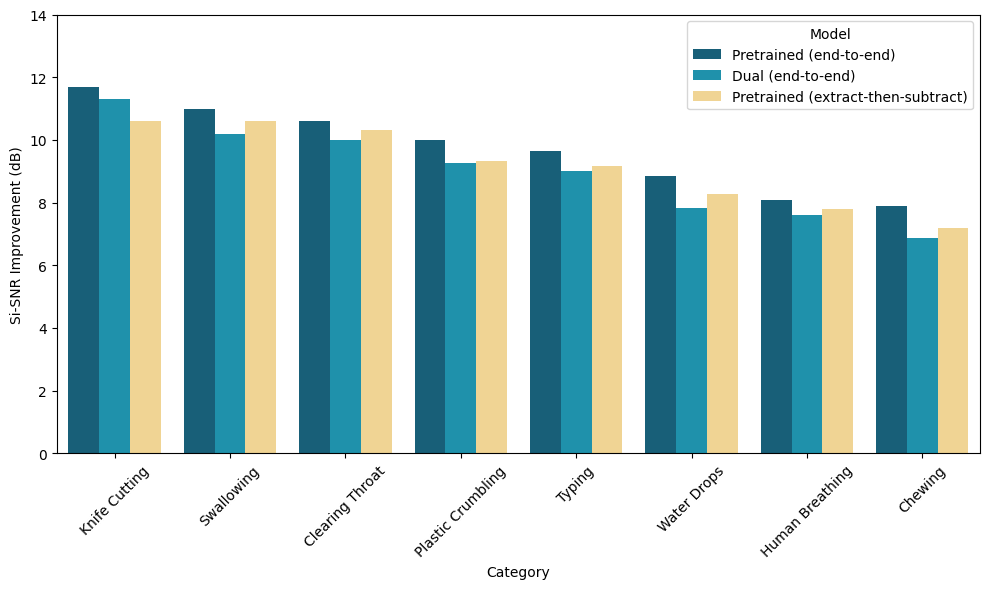

In [5]:
# Bar plot of the Si-SNRi per category between the two models, ordered by best (si_sniri_ft_e2e)
order = subtract_data.sort_values("si_sniri_ft_e2e", ascending=False)["category_pretty"].tolist()
melted = subtract_data.melt(
    id_vars=["category", "category_pretty", "count"],
    value_vars=[
        "si_sniri_ft_e2e",
        "si_sniri_sh_base_e2e",
        "si_sniri_ft_ex2s",
    ],
    var_name="model",
    value_name="si_sniri",
)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=melted,
    x="category_pretty",
    y="si_sniri",
    hue="model",
    palette={
        "si_sniri_ft_e2e": "#086788",
        "si_sniri_sh_base_e2e": "#07A0C3",
        "si_sniri_ft_ex2s": "#FFDA85",
    },
    order=order,
)

plt.xlabel("Category")
plt.ylabel("Si-SNR Improvement (dB)")

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=[
        "Pretrained (end-to-end)",
        "Dual (end-to-end)",
        "Pretrained (extract-then-subtract)",
    ],
    title="Model",
)
plt.ylim(0, 14)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(get_data_dir() / "report_figs" / "si_sniri_per_category.pdf")
plt.show()


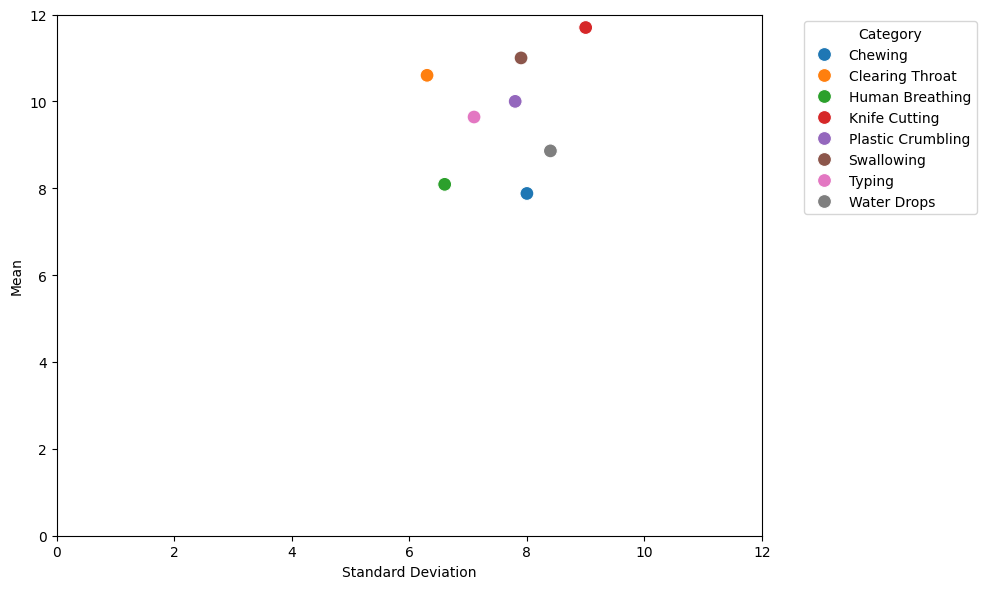

In [ ]:
# plot si_sniri_ft vs si_sniri_ft_std
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=subtract_data,
    x="si_sniri_ft_e2e_std",
    y="si_sniri_ft_e2e",
    hue="category_pretty",
    palette="tab10",
    s=100,
)
plt.xlabel("Standard Deviation")
plt.ylabel("Mean")
plt.ylim(0, 12)
plt.xlim(0, 12)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
# plt.savefig(get_data_dir() / "report_figs" / "si_sniri_ft_vs_std.pdf")
plt.show()

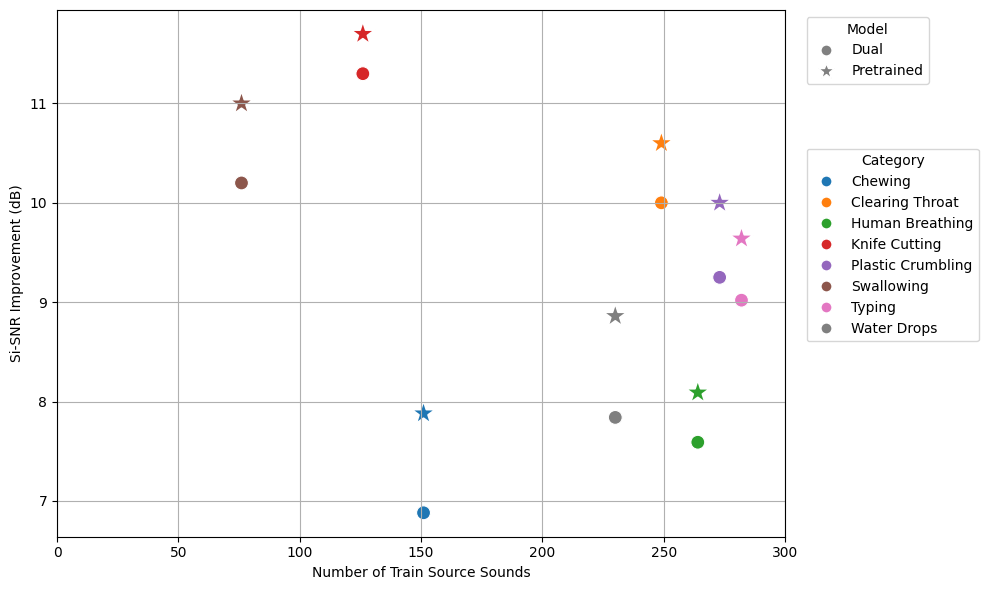

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=subtract_data,
    x="count",
    y="si_sniri_sh_base_e2e",
    hue="category_pretty",
    s=100,
    marker="o",
    legend=False,
    ax=ax,
)

sns.scatterplot(
    data=subtract_data,
    x="count",
    y="si_sniri_ft_e2e",
    hue="category_pretty",
    s=350,
    marker="*",
    legend=False,
    ax=ax,
)

ax.set_xlabel("Number of Train Source Sounds")
ax.set_ylabel("Si-SNR Improvement (dB)")

# Legend 1: model markers
model_proxies = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=8, label="Dual"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="gray", markersize=12, label="Pretrained"),
]
legend1 = ax.legend(
    handles=model_proxies,
    title="Model",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    bbox_transform=ax.transAxes,
    frameon=True,
)

# Legend 2: categories (colors) placed below model legend
colors = sns.color_palette(n_colors=len(subtract_data["category_pretty"]))
cat_proxies = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=tuple(colors[idx]), markersize=8, label=cat)
    for idx, cat in enumerate(subtract_data["category_pretty"])
]
legend2 = ax.legend(
    handles=cat_proxies,
    title="Category",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.75),
    bbox_transform=ax.transAxes,
    frameon=True,
)

ax.add_artist(legend1)

ax.grid()
ax.set_xlim(0, 300)
plt.tight_layout()
plt.savefig(get_data_dir() / "report_figs" / "count_vs_si_sniri.pdf", bbox_inches="tight")
plt.show()


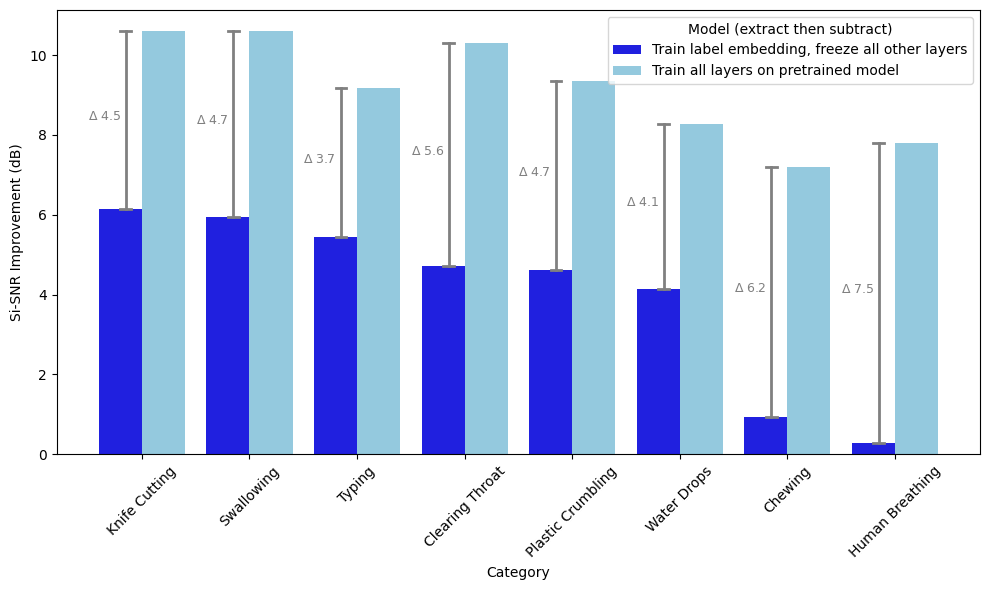

,category_pretty,si_sniri_ft_le,si_sniri_ft_ex2s,le_ft_diff
0,Chewing,0.946,7.19,6.244
1,Clearing Throat,4.720,10.30,5.580
2,Human Breathing,0.286,7.80,7.514
3,Knife Cutting,6.140,10.60,4.460
4,Plastic Crumbling,4.620,9.34,4.720
5,Swallowing,5.940,10.60,4.660
6,Typing,5.440,9.17,3.730
7,Water Drops,4.150,8.27,4.120


In [ ]:
# Plot extract_data as bar plot
order = subtract_data.sort_values("si_sniri_ft_le", ascending=False)["category_pretty"].tolist()
melted_extract = subtract_data.melt(
    id_vars=["category", "category_pretty", "count"],
    value_vars=[
        "si_sniri_ft_le",
        "si_sniri_ft_ex2s",
        # "si_sniri_sh_base_extract",
    ],
    var_name="model",
    value_name="si_sniri",
)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=melted_extract,
    x="category_pretty",
    y="si_sniri",
    hue="model",
    palette={
        "si_sniri_ft_le": "blue",
        "si_sniri_ft_ex2s": "#87CEEB",
        # "si_sniri_sh_base": "#d3d3d3",
    },
    order=order,
)

# Add vertical line showing the difference between the two models
for i, cat in enumerate(order):
    diff = subtract_data[subtract_data["category_pretty"] == cat]["le_ft_diff"].values[0]
    le_val = subtract_data[subtract_data["category_pretty"] == cat]["si_sniri_ft_le"].values[0]
    ax.plot([i - 0.15, i - 0.15], [le_val, le_val + diff], color="grey", linewidth=2)
    # Add small horizontal caps at both ends
    ax.plot([i - 0.2, i - 0.1], [le_val, le_val], color="grey", linewidth=2)
    ax.plot([i - 0.2, i - 0.1], [le_val + diff, le_val + diff], color="grey", linewidth=2)
    # Add text showing the difference
    ax.text(i - 0.5, le_val + diff / 2, f"$\Delta~{diff:.1f}$", fontsize=9, va="baseline", color="grey")

plt.xlabel("Category")
plt.ylabel("Si-SNR Improvement (dB)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=[
        "Train label embedding, freeze all other layers",
        "Train all layers on pretrained model",
        # "Dual",
    ],
    title="Model (extract then subtract)",
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(get_data_dir() / "report_figs" / "si_sniri_per_category_subtract_le.pdf")
plt.show()

display(subtract_data[["category_pretty", "si_sniri_ft_le", "si_sniri_ft_ex2s", "le_ft_diff"]])

# Extraction

In [ ]:
si_sniri_sh_base_extract = {
    "chewing": 2.57,
    "clearing_throat": 4.35,
    "human_breathing": 3.16,
    "knife_cutting": 6.15,
    "plastic_crumbling": 4.93,
    "swallowing": 3.97,
    "typing": 4.17,
    "water_drops": 3.06,
}
si_sniri_sh_ft_extract = {
    "chewing": 3.38,
    "clearing_throat": 4.61,
    "human_breathing": 3.21,
    "knife_cutting": 5.88,
    "plastic_crumbling": 4.97,
    "swallowing": 4.33,
    "typing": 4.42,
    "water_drops": 3.16,
}
si_sniri_sh_ft_le_extract = {
    "chewing": 1.03,
    "clearing_throat": 2.22,
    "human_breathing": 0.764,
    "knife_cutting": 2.88,
    "plastic_crumbling": 2.81,
    "swallowing": 2.87,
    "typing": 2.41,
    "water_drops": 1.67,
}

extract_data = pd.DataFrame(
    {
        "category": list(sorted(category_pretty.keys())),
        "category_pretty": [category_pretty[k] for k in sorted(category_pretty.keys())],
        "count": [source_sound_dist_train[k] for k in sorted(category_pretty.keys())],
        "count_all": [source_sound_dist_all[k] for k in sorted(category_pretty.keys())],
        "si_sniri_sh_base_extract": [si_sniri_sh_base_extract[k] for k in sorted(category_pretty.keys())],
        "si_sniri_sh_ft_extract": [si_sniri_sh_ft_extract[k] for k in sorted(category_pretty.keys())],
        "si_sniri_sh_ft_le_extract": [si_sniri_sh_ft_le_extract[k] for k in sorted(category_pretty.keys())],
    }
)

extract_data["ft_diff"] = extract_data["si_sniri_sh_ft_extract"] - extract_data["si_sniri_sh_ft_le_extract"]

extract_data

,category,category_pretty,count,count_all,si_sniri_sh_base_extract,si_sniri_sh_ft_extract,si_sniri_sh_ft_le_extract,ft_diff
0,chewing,Chewing,151,205,2.57,3.38,1.030,2.350
1,clearing_throat,Clearing Throat,249,337,4.35,4.61,2.220,2.390
2,human_breathing,Human Breathing,264,352,3.16,3.21,0.764,2.446
3,knife_cutting,Knife Cutting,126,188,6.15,5.88,2.880,3.000
4,plastic_crumbling,Plastic Crumbling,273,429,4.93,4.97,2.810,2.160
5,swallowing,Swallowing,76,108,3.97,4.33,2.870,1.460
6,typing,Typing,282,434,4.17,4.42,2.410,2.010
7,water_drops,Water Drops,230,326,3.06,3.16,1.670,1.490


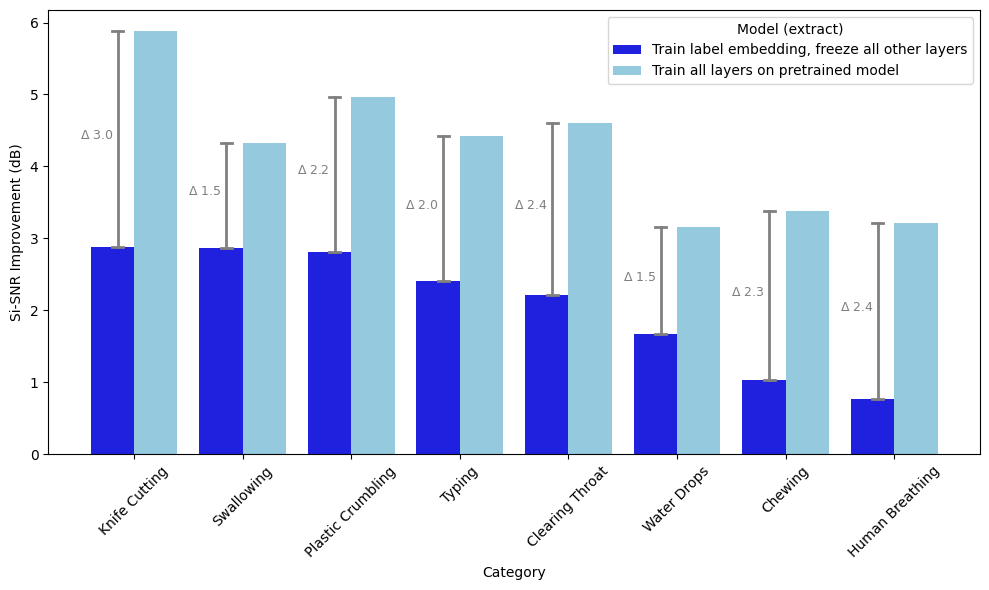

,category_pretty,si_sniri_sh_ft_le_extract,si_sniri_sh_ft_extract,ft_diff
0,Chewing,1.030,3.38,2.350
1,Clearing Throat,2.220,4.61,2.390
2,Human Breathing,0.764,3.21,2.446
3,Knife Cutting,2.880,5.88,3.000
4,Plastic Crumbling,2.810,4.97,2.160
5,Swallowing,2.870,4.33,1.460
6,Typing,2.410,4.42,2.010
7,Water Drops,1.670,3.16,1.490


In [ ]:
# Plot extract_data as bar plot
order = extract_data.sort_values("si_sniri_sh_ft_le_extract", ascending=False)["category_pretty"].tolist()
melted_extract = extract_data.melt(
    id_vars=["category", "category_pretty", "count"],
    value_vars=[
        "si_sniri_sh_ft_le_extract",
        "si_sniri_sh_ft_extract",
        # "si_sniri_sh_base_extract",
    ],
    var_name="model",
    value_name="si_sniri",
)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=melted_extract,
    x="category_pretty",
    y="si_sniri",
    hue="model",
    palette={
        "si_sniri_sh_ft_le_extract": "blue",
        "si_sniri_sh_ft_extract": "#87CEEB",
        # "si_sniri_sh_base_extract": "#d3d3d3",
    },
    order=order,
)

# Add vertical line showing the difference between the two models
for i, cat in enumerate(order):
    diff = extract_data[extract_data["category_pretty"] == cat]["ft_diff"].values[0]
    le_val = extract_data[extract_data["category_pretty"] == cat]["si_sniri_sh_ft_le_extract"].values[0]
    ax.plot([i - 0.15, i - 0.15], [le_val, le_val + diff], color="grey", linewidth=2)
    # Add small horizontal caps at both ends
    ax.plot([i - 0.2, i - 0.1], [le_val, le_val], color="grey", linewidth=2)
    ax.plot([i - 0.2, i - 0.1], [le_val + diff, le_val + diff], color="grey", linewidth=2)
    # Add text showing the difference
    ax.text(i - 0.5, le_val + diff / 2, f"$\Delta~{diff:.1f}$", fontsize=9, va="baseline", color="grey")

plt.xlabel("Category")
plt.ylabel("Si-SNR Improvement (dB)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=[
        "Train label embedding, freeze all other layers",
        "Train all layers on pretrained model",
        # "Dual",
    ],
    title="Model (extract)",
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(get_data_dir() / "report_figs" / "si_sniri_per_category_extract_le.pdf")
plt.show()

display(extract_data[["category_pretty", "si_sniri_sh_ft_le_extract", "si_sniri_sh_ft_extract", "ft_diff"]])

# Subtraction Loss

In [ ]:
# The order sifference (does it change which is the #1, #2 performer etc)
order_ex2s = subtract_data.sort_values("si_sniri_ft_ex2s", ascending=False)["category_pretty"].tolist()
order_extract = extract_data.sort_values("si_sniri_sh_ft_extract", ascending=False)["category_pretty"].tolist()

rank_df = pd.DataFrame(
    {
        "category_pretty": extract_data["category_pretty"],
        "rank_ex2s": subtract_data["si_sniri_ft_ex2s"].rank(ascending=False),
        "rank_extract": extract_data["si_sniri_sh_ft_extract"].rank(ascending=False),
    }
)
rank_df["rank_diff"] = rank_df["rank_ex2s"] - rank_df["rank_extract"]
rank_df = rank_df.sort_values("rank_extract")
rank_df

,category_pretty,rank_ex2s,rank_extract,rank_diff
3,Knife Cutting,1.5,1.0,0.5
4,Plastic Crumbling,4.0,2.0,2.0
1,Clearing Throat,3.0,3.0,0.0
6,Typing,5.0,4.0,1.0
5,Swallowing,1.5,5.0,-3.5
0,Chewing,8.0,6.0,2.0
2,Human Breathing,7.0,7.0,0.0
7,Water Drops,6.0,8.0,-2.0


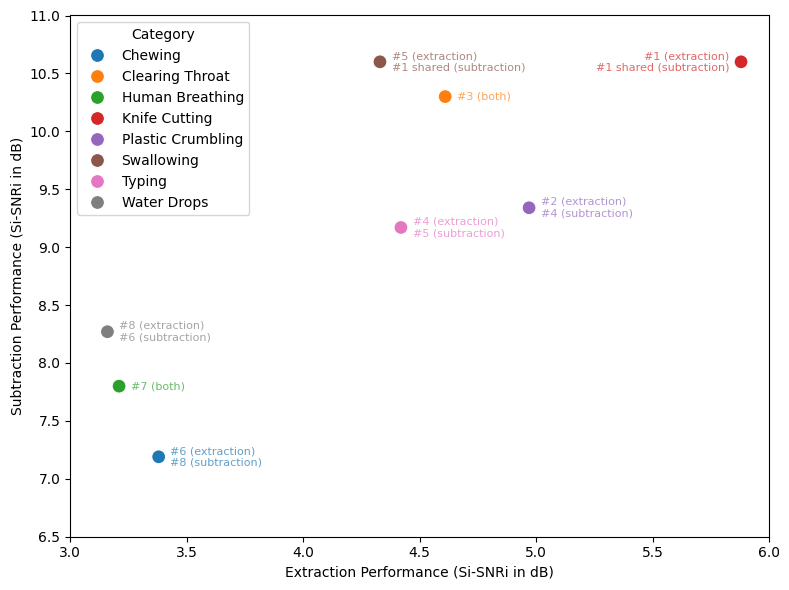

In [ ]:
# Plot  extract_data["si_sniri_sh_ft_extract"] vs subtract_data["si_sniri_ft"] as a scatter plot

import math


def plot_cat_rank_diff(
    merged,
    rank_df,
    pretty_col="category_pretty",
    x_col="si_sniri_sh_ft_extract",
    y_col="si_sniri_ft_ex2s",
    rank_x_col="rank_extract",
    rank_y_col="rank_ex2s",
    x_description="Extraction Performance (Si-SNRi in dB)",
    y_description="Subtraction Performance (Si-SNRi in dB)",
    x_short = "extraction",
    y_short = "subtraction",
    x_lim = (3, 6),
    y_lim = (6.5, 11),
    align_cutoff = 1,
    save_to=None,
    figure_size=(8, 6),
    text_fontsize=8,
    legend_kwargs={
        "loc": "upper left",
    }
):
    plt.figure(figsize=figure_size)
    colors = sns.color_palette(n_colors=len(merged[pretty_col]))
    ax = sns.scatterplot(
        data=merged,
        x=x_col,
        y=y_col,
        hue=pretty_col,
        palette=colors,
        s=100,
    )

    for i in range(len(merged)):
        cat = merged.iloc[i][pretty_col]
        rank_ex2s = rank_df[rank_df[pretty_col] == cat][rank_y_col].values[0]
        rank_extract = rank_df[rank_df[pretty_col] == cat][rank_x_col].values[0]

        rank_extract_txt = f"#{math.floor(rank_extract)} shared" if rank_extract % 1 != 0 else f"#{int(rank_extract)}"
        rank_subtract_txt = f"#{math.floor(rank_ex2s)} shared" if rank_ex2s % 1 != 0 else f"#{int(rank_ex2s)}"
        txt = (
            f"{rank_extract_txt} (both)"
            if rank_extract_txt == rank_subtract_txt
            else f"{rank_extract_txt} ({x_short})\n{rank_subtract_txt} ({y_short})"
        )

        cat_color = colors[merged[pretty_col].tolist().index(cat)]
        left_align = rank_extract > align_cutoff
        ax.text(
            merged.iloc[i][x_col] + 0.05 if left_align else merged.iloc[i][x_col] - 0.05,
            merged.iloc[i][y_col],
            txt,
            fontsize=text_fontsize,
            ha="left" if left_align else "right",
            va="center",
            color=cat_color,
            alpha=0.7,
        )

    plt.xlabel(x_description)
    plt.ylabel(y_description)
    plt.xlim(*x_lim)
    plt.ylim(*y_lim)
    plt.legend(
        title="Category",
        **legend_kwargs
    )
    plt.tight_layout()
    if save_to:
        plt.savefig(save_to)
    plt.show()


merged = pd.merge(
    extract_data[["category_pretty", "si_sniri_sh_ft_extract"]],
    subtract_data[["category_pretty", "si_sniri_ft_ex2s"]],
    on="category_pretty",
)
plot_cat_rank_diff(merged, rank_df, save_to=get_data_dir() / "report_figs" / "category_extract_vs_subtract.pdf")

# Val vs. test

In [ ]:
from pathlib import Path
import pandas as pd
import json
from misophonia_dataset.interface import get_data_dir

In [ ]:
def load_from_json(p: Path) -> pd.DataFrame:
    with p.open() as f:
        data = json.load(f)
    by_cat = []
    for k, v in data.items():
        if k.startswith("by:fg_categories="):
            # __grouped_by__
            cats = v["__grouped_by__"]["fg_categories"]
            if len(cats) == 1:
                cat = cats[0]
                by_cat.append({"category": cat, **v["x"]})
    df = pd.DataFrame(by_cat)
    return df


base_dir = get_data_dir() / "model-aux-ft-all-gt-clean-mix" / "eval_results"
val_res = load_from_json(base_dir / "ema_best_by_ema_val_aggregated_results.json")
test_res = load_from_json(base_dir / "ema_best_by_ema_test_aggregated_results.json")

In [ ]:
category_pretty_2 = {
    "chewing_gum": "Chewing",
    "clearing_throat": "Clearing Throat",
    "human_breathing": "Human Breathing",
    "knife_cutting": "Knife Cutting",
    "plastic_crumpling": "Plastic Crumpling",
    "swallowing": "Swallowing",
    "typing": "Typing",
    "water_drops": "Water Drops",
}
valtest_res = pd.merge(
    val_res[["category", "si_snr_improvement_mean"]].rename(columns={"si_snr_improvement_mean": "val_si_snr_improvement_mean"}),
    test_res[["category", "si_snr_improvement_mean"]].rename(columns={"si_snr_improvement_mean": "test_si_snr_improvement_mean"}),
    on="category",
)
valtest_res["category_pretty"] = valtest_res["category"].map(category_pretty_2)

rank_df_valtest = pd.DataFrame(
    {
        "category_pretty": valtest_res["category_pretty"],
        "rank_val": valtest_res["val_si_snr_improvement_mean"].rank(ascending=False),
        "rank_test": valtest_res["test_si_snr_improvement_mean"].rank(ascending=False),
    }
)
rank_df_valtest["rank_diff"] = rank_df_valtest["rank_val"] - rank_df_valtest["rank_test"]
rank_df_valtest = rank_df_valtest.sort_values("rank_val")

display(valtest_res)
display(rank_df_valtest)

,category,val_si_snr_improvement_mean,test_si_snr_improvement_mean,category_pretty
0,chewing_gum,10.120708,7.878905,Chewing
1,clearing_throat,8.540322,10.619443,Clearing Throat
2,human_breathing,8.055718,8.090323,Human Breathing
3,knife_cutting,10.877602,11.707033,Knife Cutting
4,plastic_crumpling,10.726611,10.035121,Plastic Crumpling
5,swallowing,7.563776,11.004210,Swallowing
6,typing,11.267953,9.643509,Typing
7,water_drops,10.434765,8.855987,Water Drops


,category_pretty,rank_val,rank_test,rank_diff
6,Typing,1.0,5.0,-4.0
3,Knife Cutting,2.0,1.0,1.0
4,Plastic Crumpling,3.0,4.0,-1.0
7,Water Drops,4.0,6.0,-2.0
0,Chewing,5.0,8.0,-3.0
1,Clearing Throat,6.0,3.0,3.0
2,Human Breathing,7.0,7.0,0.0
5,Swallowing,8.0,2.0,6.0


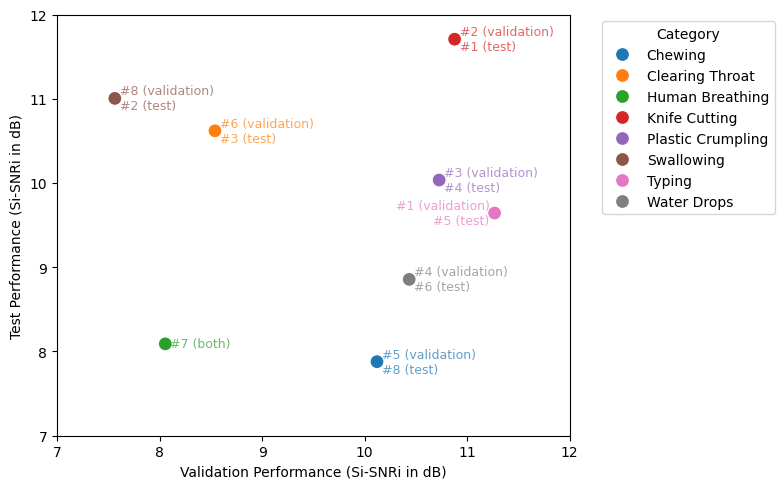

In [ ]:
plot_cat_rank_diff(
    valtest_res,
    rank_df_valtest,
    x_col="val_si_snr_improvement_mean",
    y_col="test_si_snr_improvement_mean",
    x_description="Validation Performance (Si-SNRi in dB)",
    y_description="Test Performance (Si-SNRi in dB)",
    x_short="validation",
    y_short="test",
    rank_x_col="rank_val",
    rank_y_col="rank_test",
    x_lim=(7, 12),
    y_lim=(7, 12),
    align_cutoff=1,
    save_to=get_data_dir() / "report_figs" / "category_val_vs_test.pdf",
    figure_size=(8, 5),
    text_fontsize=9,
    legend_kwargs={
        "loc": "upper left",
        # Outside of the plot
        "bbox_to_anchor": (1.05, 1),
    }
)